In [1]:
import torch
import numpy as np

import os

from sklearn.decomposition import PCA
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
device

device(type='cpu')

In [3]:
output_path = '/data/scratch/hmz574/clipped_database/encoded/'
processed_files = os.listdir(output_path)
processed_files[0:10]

[]

In [7]:
pcs = False

In [8]:
pooled_features = []
pooled_names = []
if pcs:
    for file_name in processed_files:
        pooled_names.append(file_name)
        data = torch.load(output_path+file_name)
        data = data.mean(0)
        pooled_features.append(data.detach().numpy())


In [9]:
if pcs:
    pooled_array = np.array(pooled_features)
    pca = PCA(n_components=8)
    pca_features = pca.fit_transform(pooled_array)

In [10]:
pca_features = []
pca_names = []
for file_name in processed_files:
    pooled_names.append(file_name)
    data = torch.load(output_path+file_name, weights_only=True)
    if data.shape[0] == 30:
        pca_names.append(file_name)
        if pcs:
            data = pca.transform(data.detach().numpy())
        else: data = data.detach().numpy()
        pca_features.append(data)

In [11]:
classes = []
for name in pca_names:
    classes.append(name.split('_')[1])
    
batches = []
for name in pca_names:
    batches.append(name.split('_')[0])
    

In [12]:
pca_features = np.array(pca_features)
pca_features.shape

(1625, 30, 384)

In [ ]:
(1625, 30, 384)

In [13]:
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [26]:
from transformers import DistilBertConfig, DistilBertForSequenceClassification
dim = pca_features.shape[2]
configuration = DistilBertConfig(dim=dim,n_heads = 8,num_labels=9, n_layers=10)


In [27]:
configuration

DistilBertConfig {
  "activation": "gelu",
  "attention_dropout": 0.1,
  "dim": 384,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5,
    "LABEL_6": 6,
    "LABEL_7": 7,
    "LABEL_8": 8
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 8,
  "n_layers": 10,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "transformers_version": "4.55.1",
  "vocab_size": 30522
}

In [28]:
model = DistilBertForSequenceClassification(configuration).to(device)

In [29]:
class_to_int = {
    'groom': 0,
    'rest': 1,
    'eat': 2,
    'hang': 3,
    'rear': 4,
    'drink': 5,
    'head': 6,
    'groomback': 0,
    'walk': 7,
}

labels = [class_to_int[x] for x in classes]
labels = torch.tensor(labels, dtype=torch.int64)

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(
    torch.Tensor(pca_features), labels, test_size=0.25, random_state=42)

In [31]:
X_train.shape

torch.Size([1218, 30, 384])

In [32]:
Y_train.shape

torch.Size([1218])

In [33]:
Y_test

tensor([0, 5, 3, 3, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 7, 6, 2, 0, 0, 0, 3, 1, 1,
        1, 1, 0, 1, 5, 7, 1, 1, 0, 1, 0, 0, 1, 1, 1, 7, 0, 0, 1, 3, 1, 1, 0, 1,
        1, 3, 1, 3, 4, 0, 3, 1, 0, 1, 4, 1, 1, 0, 0, 2, 3, 1, 1, 3, 1, 1, 1, 3,
        1, 1, 0, 0, 5, 2, 1, 0, 3, 0, 2, 1, 5, 1, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0,
        2, 2, 1, 3, 1, 0, 1, 0, 0, 0, 0, 4, 0, 0, 1, 6, 0, 1, 0, 1, 0, 0, 1, 2,
        1, 0, 0, 0, 0, 0, 3, 4, 1, 0, 0, 1, 1, 4, 3, 4, 1, 3, 1, 5, 1, 2, 0, 0,
        1, 1, 1, 1, 2, 0, 1, 1, 1, 1, 3, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 2,
        0, 4, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 3, 0, 0, 0, 0, 2, 1, 0, 2, 4, 0, 2,
        1, 1, 1, 1, 0, 0, 1, 0, 6, 0, 1, 0, 0, 1, 0, 1, 2, 3, 1, 0, 1, 0, 1, 1,
        1, 1, 0, 0, 1, 0, 4, 1, 0, 4, 2, 4, 1, 2, 2, 0, 4, 1, 0, 3, 0, 0, 3, 1,
        0, 0, 2, 1, 1, 0, 1, 0, 1, 1, 2, 3, 4, 1, 0, 1, 1, 0, 1, 0, 0, 3, 0, 1,
        1, 1, 1, 0, 1, 1, 2, 0, 1, 1, 0, 0, 0, 0, 0, 2, 2, 0, 1, 0, 2, 1, 1, 0,
        1, 3, 1, 0, 1, 1, 1, 1, 0, 1, 1,

In [38]:
# batch_size, epoch and iteration
batch_size = 500
n_iters = 25000
num_epochs = n_iters / (len(X_train) / batch_size)
num_epochs = int(num_epochs)

# Pytorch train and test sets
train = TensorDataset(X_train, Y_train)
test = TensorDataset(X_test,Y_test)

# data loader
train_loader = DataLoader(train, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test, batch_size = batch_size, shuffle = True)

In [39]:
error = nn.CrossEntropyLoss()
# SGD Optimizer
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [40]:
seq_dim = 30  
loss_list = []
iteration_list = []
accuracy_list = []
count = 0

In [ ]:

for epoch in range(num_epochs):
    for i, (train, targets) in enumerate(train_loader):

            
        # Clear gradients
        optimizer.zero_grad()
        model.train()
        
        # Forward propagation
        outputs = model(inputs_embeds = train.to(device))
        
        # Calculate softmax and ross entropy loss
        loss = error(outputs.logits, targets.to(device))
        
        # Calculating gradients
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        count += 1
        
        if count % 100 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            with torch.no_grad():
                for (test, test_targets) in test_loader:
                    model.eval()
                    # Forward propagation
                    outputs = model(inputs_embeds = test.to(device)).logits.argmax(dim=1)
                    
                    total += len(outputs)
                    correct += (outputs == test_targets.to(device)).sum()
                
                # store loss and iteration
                accuracy = correct*100/total
                loss_list.append(loss.data)
                iteration_list.append(count)
                accuracy_list.append(accuracy)
                
                # Print Loss
                print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))

Iteration: 100  Loss: 0.681428074836731  Accuracy: 84.27518463134766 %
Iteration: 200  Loss: 0.558726966381073  Accuracy: 87.46928405761719 %
Iteration: 300  Loss: 0.5072033405303955  Accuracy: 88.69778442382812 %
Iteration: 400  Loss: 0.4799653887748718  Accuracy: 89.92628479003906 %
Iteration: 500  Loss: 0.42766401171684265  Accuracy: 90.17198944091797 %
Iteration: 600  Loss: 0.40283462405204773  Accuracy: 90.90908813476562 %
Iteration: 700  Loss: 0.3590990900993347  Accuracy: 91.4004898071289 %
Iteration: 800  Loss: 0.3120209872722626  Accuracy: 91.64618682861328 %
Iteration: 900  Loss: 0.28743889927864075  Accuracy: 91.89189147949219 %
Iteration: 1000  Loss: 0.275939017534256  Accuracy: 92.62899017333984 %
Iteration: 1100  Loss: 0.2372378557920456  Accuracy: 92.13758850097656 %
Iteration: 1200  Loss: 0.2082100212574005  Accuracy: 92.87469482421875 %
Iteration: 1300  Loss: 0.20212845504283905  Accuracy: 93.6117935180664 %
Iteration: 1400  Loss: 0.199372798204422  Accuracy: 93.611793

In [51]:
torch.save(model, '2layer_model.pt')

In [23]:
device

device(type='cuda')

In [24]:
import matplotlib.pyplot as plt

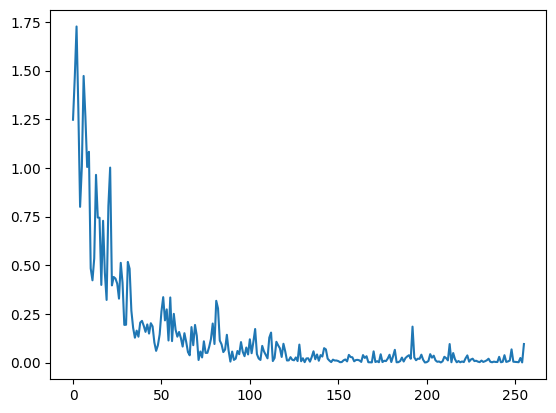

In [25]:
plt.plot(np.array([x.to('cpu') for x in loss_list]))

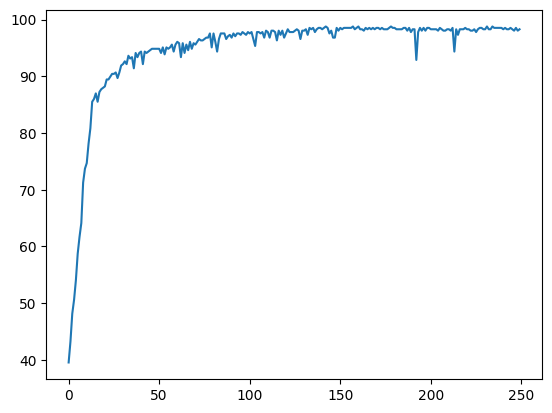

In [26]:
plt.plot(np.array([x.to('cpu') for x in accuracy_list])[:250])

In [27]:
np.array([x.to('cpu') for x in accuracy_list])[:250].max()

np.float32(98.7715)

In [ ]:
learning_rate = 0.0002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
a = model(inputs_embeds = X_test).logits
a.argmax(dim=1)

In [85]:
Y_test[1] == a.argmax(dim=1)[1]

tensor(False)

In [86]:
(a.argmax(dim=1) == Y_test).sum()

tensor(146)

In [53]:
out = model.rnn(torch.tensor(pca_features).cuda())
out = out[1].cpu().detach().numpy()[0]

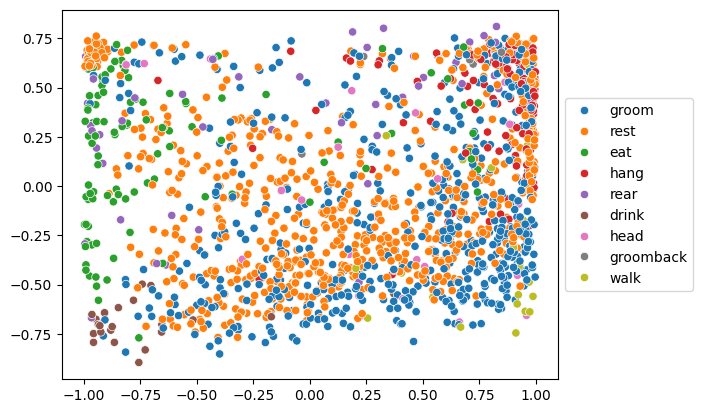

In [54]:
ax = sns.scatterplot(x = out[:,0],y = out[:,1], hue = classes)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

/data/home/hhy696/.conda/envs/torchgpu/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


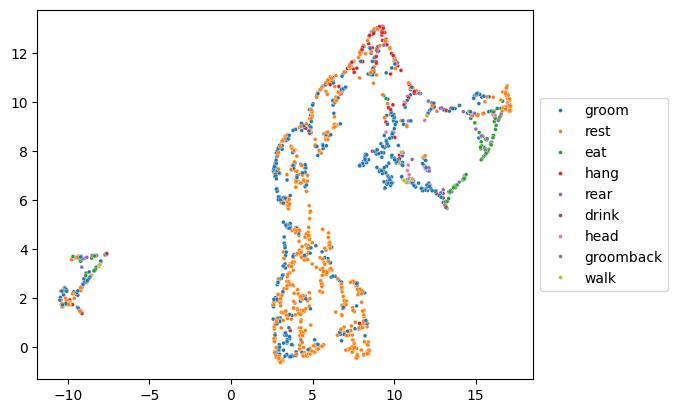

In [55]:
reducer = umap.UMAP()

scaled_features = StandardScaler().fit_transform(out)
embedding = reducer.fit_transform(scaled_features)
embedding.shape

ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], s=8,hue=classes)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

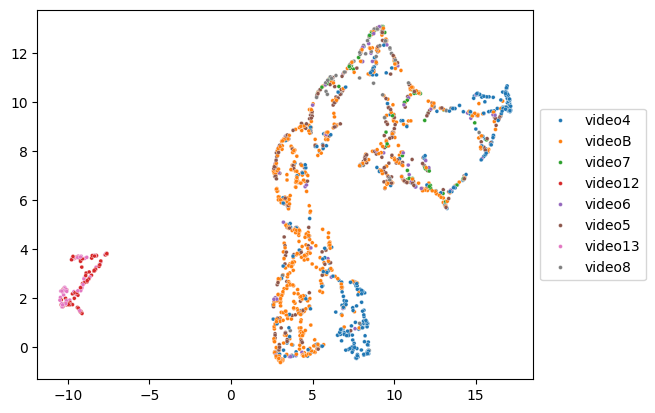

In [56]:
ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], s=8,hue=batches)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)